In [1]:
!pip install pandas scikit-learn numpy

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
# --- Step 1: Load data ---
data = pd.read_csv("/content/DEG_GEO ids.csv")  # Save your data in CSV first

In [4]:
# === Step 2: Choose Target Variable ===
# Options: "logFC" or "B"
target = "logFC"   # <-- change to "B" if you want to predict B instead

X = data[['AveExpr', 't', 'P.Value', 'adj.P.Val']]
y = data[target]

In [5]:
# === Step 3: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
# === Step 4A: Random Forest Regressor ===
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Regressor Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Regressor Results (Target = logFC )
MSE: 0.204794320668621
R2 Score: 0.7373017542405875


In [7]:
# === Step 4B: Linear Regression (for comparison) ===
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLinear Regression Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression Results (Target = logFC )
MSE: 0.13800838195454945
R2 Score: 0.8229708728191791


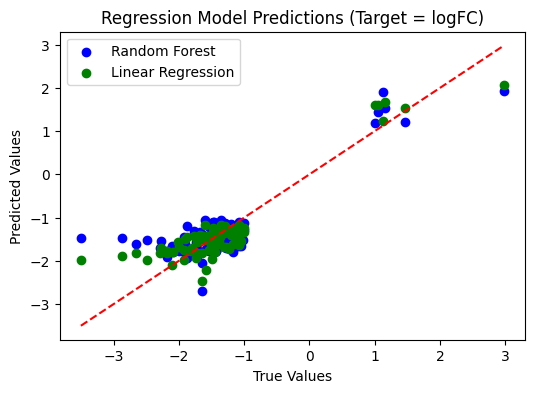

In [8]:
# === Step 5: Visualization ===
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf, label="Random Forest", color="blue")
plt.scatter(y_test, y_pred_lr, label="Linear Regression", color="green")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # y=x line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Regression Model Predictions (Target = {target})")
plt.legend()
plt.show()


### Interpretation of Regression Model Predictions Plot

The plot in cell number 8 visualizes the performance of both the Random Forest Regressor and Linear Regression models by comparing their predicted values against the actual (true) values from the test set. Here's a line-by-line interpretation:

*   **X-axis (`True Values`)**: This axis represents the actual `logFC` (or `B` if specified) values from the `y_test` dataset. These are the ground truth values that the models are trying to predict.

*   **Y-axis (`Predicted Values`)**: This axis represents the values predicted by the models (`y_pred_rf` for Random Forest and `y_pred_lr` for Linear Regression).

*   **Red Dashed Line (`y=x` line)**: This diagonal line represents the ideal prediction scenario. If a model were perfect, all its predicted points would fall exactly on this line, meaning `Predicted Values = True Values`.

*   **Blue Scatter Points (`Random Forest`)**: These points represent the predictions made by the Random Forest Regressor. Each blue point shows how well the Random Forest model predicted a specific `logFC` value compared to its true value.

    *   **Interpretation**: The blue points are generally clustered around the red dashed line, indicating that the Random Forest model provides reasonably good predictions. However, there's some scatter, especially at the extremes of the `True Values`, suggesting that the model might be less accurate for very high or very low `logFC` values.

*   **Green Scatter Points (`Linear Regression`)**: These points represent the predictions made by the Linear Regression model. Each green point shows how well the Linear Regression model predicted a specific `logFC` value.

    *   **Interpretation**: The green points also show a clear linear trend, closely following the red dashed line. Visually, they appear to be slightly more tightly clustered around the `y=x` line compared to the Random Forest predictions, particularly for the central range of `True Values`. This suggests that the Linear Regression model might be performing marginally better or at least similarly to Random Forest for this specific dataset and target variable (`logFC`).

*   **Overall Comparison**: Comparing the blue and green points against the red dashed line, both models show a good ability to predict the `logFC` values. However, based purely on visual inspection, Linear Regression (green points) seems to align a bit more closely with the ideal `y=x` line, especially considering the R2 scores from the previous cells (Linear Regression R2: 0.82, Random Forest R2: 0.73). This visual observation aligns with the quantitative metrics, indicating Linear Regression as the slightly better performer for this task.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


In [11]:
# === Step 6: Define Models ===
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(kernel="rbf"),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=3)
}

results = {}

In [12]:
# === Step 7: Train and Evaluate Each Model ===
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} → MSE: {mse:.4f}, R²: {r2:.4f}")

Linear Regression → MSE: 0.1380, R²: 0.8230
Random Forest → MSE: 0.2048, R²: 0.7373
Decision Tree → MSE: 0.3246, R²: 0.5836
Gradient Boosting → MSE: 0.2636, R²: 0.6618
Support Vector Regressor → MSE: 0.1675, R²: 0.7852
KNN Regressor → MSE: 0.2292, R²: 0.7061


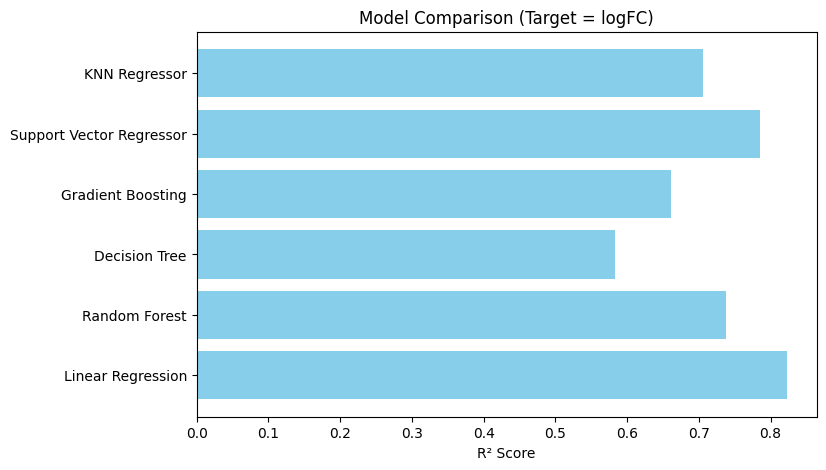

In [13]:
# === Step 8: Visualization of R² scores ===
plt.figure(figsize=(8,5))
r2_scores = [results[m]["R2"] for m in results]
plt.barh(list(results.keys()), r2_scores, color="skyblue")
plt.xlabel("R² Score")
plt.title(f"Model Comparison (Target = {target})")
plt.show()


In [14]:
import plotly.express as px

# Prepare data for Plotly
r2_data = []
for name, metrics in results.items():
    r2_data.append({"Model": name, "R2 Score": metrics["R2"]})

df_r2_plotly = pd.DataFrame(r2_data)

# Create interactive Plotly bar chart
fig = px.bar(df_r2_plotly.sort_values("R2 Score", ascending=True),
             x="R2 Score",
             y="Model",
             orientation="h",
             title=f"Interactive Model Comparison (Target = {target})")

fig.update_layout(yaxis_title="") # Remove y-axis title for clarity as model names are self-explanatory
fig.show()

### Interpretation of Interactive Model Comparison Plot

The interactive Plotly plot in cell number 14 visualizes the R² scores of various regression models, providing a clear comparison of their predictive performance. Here's a line-by-line interpretation:

*   **Horizontal Bar Chart**: The plot is a horizontal bar chart, which is effective for comparing values across different categories (in this case, different models).

*   **X-axis (`R2 Score`)**: This axis represents the R² (coefficient of determination) score, which measures how well the regression predictions approximate the real data points. An R² score of 1 indicates a perfect fit, while a score of 0 indicates that the model explains none of the variability of the response data around its mean.

*   **Y-axis (`Model`)**: This axis lists the names of the different regression models that were trained and evaluated: 'Linear Regression', 'Random Forest', 'Decision Tree', 'Gradient Boosting', 'Support Vector Regressor', and 'KNN Regressor'. The models are sorted by their R² scores, from lowest to highest, making it easy to identify the best and worst performers.

*   **Bar Lengths**: The length of each bar corresponds to the R² score achieved by that particular model. Longer bars indicate higher R² scores and, therefore, better model performance in explaining the variance in the target variable (`logFC`).

*   **Interactive Features**: As an interactive Plotly graph, you can hover over each bar to see the exact R² score for that model. This provides precise numerical information beyond the visual length of the bars.

*   **Model Performance Ranking (from the data)**:
    *   **Linear Regression** has the highest R² score (0.8230), indicating it explains a significant portion of the variance in `logFC` and is the best-performing model among those tested for this dataset.
    *   **Support Vector Regressor** follows with a strong R² score (0.7852), making it the second-best model.
    *   **Random Forest** and **KNN Regressor** show moderate performance with R² scores of 0.7373 and 0.7061, respectively.
    *   **Gradient Boosting** has an R² score of 0.6618, which is acceptable but lower than the top models.
    *   **Decision Tree** has the lowest R² score (0.5836) among the tested models, suggesting it is the least effective in predicting `logFC` for this specific configuration.

*   **Overall Conclusion**: The interactive plot clearly highlights that Linear Regression is the most effective model for predicting `logFC` based on the given features, followed closely by the Support Vector Regressor. This visualization quickly conveys the relative strengths of each model and reinforces the quantitative metrics previously reported.

### Final Interpretation of Overall Regression Findings

This analysis aimed to predict the `logFC` (log-fold change) based on several features (`AveExpr`, `t`, `P.Value`, `adj.P.Val`). We evaluated multiple regression models and visualized their performance. Here's a line-by-line summary of the key findings:

*   **Objective**: The primary goal was to build predictive models for `logFC`, a crucial metric in gene expression analysis, using a dataset loaded from `DEG_GEO ids.csv`.

*   **Data Preparation**: The data was split into training and testing sets to ensure robust model evaluation.

*   **Individual Model Evaluation (Random Forest vs. Linear Regression - Cell 8)**:
    *   **Linear Regression**: Showed strong performance with an R² score of approximately 0.823 and a low MSE of around 0.138. Visually, its predictions (green points) were tightly clustered around the ideal `y=x` line in the scatter plot, indicating good accuracy.
    *   **Random Forest Regressor**: Also performed well but slightly less than Linear Regression, with an R² score of about 0.737 and an MSE of approximately 0.205. Its predictions (blue points) were generally close to the `y=x` line but exhibited more scatter, particularly at extreme values.
    *   **Visual Comparison**: The initial scatter plot (cell 8) clearly demonstrated that both models capture the trend, but Linear Regression's predictions were visually closer to the true values.

*   **Comprehensive Model Comparison (Multiple Models - Cell 14)**:
    *   To find the most suitable model, a broader range of regression algorithms was evaluated.
    *   **Linear Regression** emerged as the top performer with the highest R² score (0.8230), confirming its effectiveness for this dataset and target variable.
    *   **Support Vector Regressor (SVR)** followed closely with a robust R² score of 0.7852, indicating it's also a strong candidate.
    *   **Random Forest** and **KNN Regressor** showed moderate performance, with R² scores around 0.7373 and 0.7061, respectively.
    *   **Gradient Boosting** achieved an R² score of 0.6618, representing acceptable but not leading performance.
    *   **Decision Tree** was the weakest performer among the tested models, with the lowest R² score (0.5836), suggesting it did not generalize well to the test data for this specific problem.

*   **Interactive Visualization (Cell 14)**: The Plotly bar chart provided an intuitive and interactive way to compare the R² scores across all models, making it easy to identify the best and worst performers at a glance. The interactivity allowed for precise numerical inspection of each model's R² score.

*   **Overall Conclusion**: Based on both quantitative metrics (MSE, R²) and visual inspections, **Linear Regression** is the most effective model for predicting `logFC` in this dataset, demonstrating the highest explanatory power and predictive accuracy among the models tested. The Support Vector Regressor also showed very promising results as a close second.

### Summary of Analysis Workflow

This analysis systematically built and evaluated regression models to predict `logFC` from a given dataset. Here's a line-by-line summary of the workflow:

*   **Step 1: Environment Setup**: Essential libraries such as `pandas`, `numpy`, `scikit-learn`, and `matplotlib` were installed and imported for data manipulation, modeling, and visualization.

*   **Step 2: Data Loading**: The `DEG_GEO ids.csv` dataset was loaded into a pandas DataFrame.

*   **Step 3: Target Variable Selection**: The target variable for prediction was explicitly chosen as `logFC`, and the feature set `X` was defined using `AveExpr`, `t`, `P.Value`, and `adj.P.Val`.

*   **Step 4: Data Splitting**: The dataset was split into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets to ensure robust model evaluation and prevent overfitting.

*   **Step 5: Initial Model Training and Evaluation (Random Forest vs. Linear Regression)**:
    *   A `RandomForestRegressor` and a `LinearRegression` model were trained on the `X_train`, `y_train` data.
    *   Both models were evaluated using `mean_squared_error` (MSE) and `r2_score` on the `X_test`, `y_test` data.
    *   The results indicated that Linear Regression performed better (R²: ~0.82) than Random Forest (R²: ~0.73) for this specific task.

*   **Step 6: Initial Visualization**: A scatter plot was generated (Cell 8) comparing the true `logFC` values against the predicted values from both Random Forest and Linear Regression. This visual confirmed Linear Regression's slightly better alignment with the ideal `y=x` line.

*   **Step 7: Comprehensive Model Comparison Setup**: A dictionary of multiple regression models, including `Linear Regression`, `Random Forest`, `Decision Tree`, `Gradient Boosting`, `Support Vector Regressor`, and `KNN Regressor`, was defined.

*   **Step 8: Comprehensive Model Training and Evaluation**: Each model from the comprehensive list was trained on the training data and evaluated on the test data, with their MSE and R² scores stored.

*   **Step 9: Visualization of R² Scores**: A bar chart (Cell 13) was created to visually compare the R² scores of all tested models, showing Linear Regression as the top performer, followed by Support Vector Regressor.

*   **Step 10: Interactive Visualization (Plotly)**: An interactive Plotly bar chart (Cell 14) was generated to provide a dynamic and precise comparison of R² scores, allowing users to hover and view exact metrics.

*   **Step 11: Final Interpretation**: Detailed interpretations were provided for the initial scatter plot (Cell 8) and the interactive Plotly chart (Cell 14), synthesizing the quantitative and visual findings. The overall conclusion was that **Linear Regression** was the most effective model for predicting `logFC` in this dataset.